
# Intrusive PCE MPC With Fixed-Order Internal Feedback

This notebook keeps a **fixed intrusive PCE order** and introduces internal feedback directly in the PCE coefficients:

$$
 x_i(\xi) = x_i^{(0)} + \sum_{\ell=1}^{P} x_i^{(\ell)} \Phi_\ell(\xi),
 \qquad
 u_i(\xi) = u_i^{(0)} + \sum_{\ell=1}^{P} u_i^{(\ell)} \Phi_\ell(\xi).
$$

Instead of optimizing every input coefficient independently, only the mean input is optimized online,

$$
 u_i^{(0)} = v_i,
 \qquad
 u_i^{(\ell)} = K x_i^{(\ell)}, \quad \ell = 1, \dots, P,
$$

so the lifted intrusive dynamics become

$$
 X_{i+1} = (A_{\mathrm{pce}} + B_{\mathrm{pce}} S_K) X_i + B_{\mathrm{pce}} S_v v_i.
$$

The notebook compares two fixed-order formulations:

- `Open-loop lifted input`: only the mean input is optimized and the higher input coefficients are zero.
- `Internal feedback`: the higher input coefficients are generated from the higher state coefficients through a fixed offline gain `K`.

In this development notebook, the MPC cost and actuator constraints remain on the optimized mean input `v_i`; the higher-order input coefficients only modify the intrusive prediction model.


In [1]:
from pathlib import Path
import sys
import warnings
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import linalg
import casadi as cas
import requests

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 4)

repo_candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, Path(".").resolve(), Path("..").resolve(), Path("../..").resolve()]
I4B_ROOT = next((path for path in repo_candidates if (path / "src").exists() and (path / "data").exists()), None)
if I4B_ROOT is None:
    raise FileNotFoundError("Could not locate the i4b repository root from the current working directory.")
if str(I4B_ROOT) not in sys.path:
    sys.path.insert(0, str(I4B_ROOT))

import src.disturbances as disturbances
import src.models.model_buildings as model_buildings
import src.models.model_buildings_pce as model_buildings_pce
import src.models.model_hvac as model_hvac
from src.controller.pc_mpc.intrusive_evaluation import (
    build_intrusive_mpc_solver,
    extract_intrusive_trajectory,
    lower_quantile_from_moments,
    realized_stage_cost,
    room_moments_from_state_traj,
)
from data.buildings import i4c


In [2]:
method = "2R2C"
pce_order = 2

h = 3600
nk = 24
closed_loop_steps = 24

constraint_handling = "hard"  # choose from: "hard", "soft"
eps_chance = 0.05
ws = 0.2
mdot_hp = 0.25

theta_bar = np.ones(2)
L = np.diag([0.2, 0.1])
closed_loop_interval_level = 0.95

controller_cases = {
    "Mean-constrained": None,
    "Chance-constrained": eps_chance,
}
formulation_color_map = {
    "Open-loop lifted input": "tab:blue",
    "Internal feedback": "tab:green",
}
disturbance_cols = ["T_amb", "Qdot_gains", "T_room_set_lower", "grid"]

grid_price_bidding_zone = "DE-LU"
grid_price_timezone = "Europe/Berlin"
grid_price_search_start_local = "2025-01-01 00:00"
grid_price_search_end_local = "2025-02-15 00:00"

grid_source_label = ""
grid_window_local = None

if constraint_handling not in {"hard", "soft"}:
    raise ValueError("constraint_handling must be 'hard' or 'soft'.")

soft_lower_constraint = constraint_handling == "soft"



## Fixed-Order Lifted Dynamics And Internal-Feedback Coupling

For the intrusive building model we assemble the lifted coefficient dynamics

$$
\dot X = A_{\mathrm{pce}} X + B_{\mathrm{pce}} U + E_{\mathrm{pce}} p,
$$

with coefficient-major stacking

$$
X = \begin{bmatrix} x^{(0)} \\ x^{(1)} \\ \vdots \\ x^{(P)} \end{bmatrix},
\qquad
U = \begin{bmatrix} u^{(0)} \\ u^{(1)} \\ \vdots \\ u^{(P)} \end{bmatrix}.
$$

The internal-feedback structure is imposed through

$$
U = S_v v + S_K X,
$$

where `S_v` places the decision variable `v` into the zero-th coefficient slot and `S_K` applies `K` only to the higher state-coefficient blocks.


In [3]:
nominal_building = model_buildings.Building(
    params=i4c,
    mdot_hp=mdot_hp,
    method=method,
    T_room_set_lower=20,
)

hp_model = model_hvac.Heatpump_AW(mdot_HP=mdot_hp)


def fetch_germany_day_ahead_prices(start_local, end_local, bidding_zone=grid_price_bidding_zone, timezone=grid_price_timezone):
    start_ts = pd.Timestamp(start_local).tz_localize(timezone)
    end_ts = pd.Timestamp(end_local).tz_localize(timezone)
    response = requests.get(
        "https://api.energy-charts.info/price",
        params={
            "bzn": bidding_zone,
            "start": start_ts.tz_convert("UTC").strftime("%Y-%m-%dT%H:%MZ"),
            "end": end_ts.tz_convert("UTC").strftime("%Y-%m-%dT%H:%MZ"),
        },
        timeout=30,
    )
    response.raise_for_status()
    payload = response.json()
    price_index = pd.to_datetime(payload["unix_seconds"], unit="s", utc=True).tz_convert(timezone)
    price_series = pd.Series(payload["price"], index=price_index, name="spot_eur_per_mwh").sort_index()
    price_series = price_series[~price_series.index.duplicated(keep="last")]

    min_step = price_series.index.to_series().diff().dropna().min()
    if pd.isna(min_step) or min_step <= pd.Timedelta(hours=1):
        price_hourly = price_series.resample(f"{h}s").mean()
    else:
        price_hourly = price_series.resample(f"{h}s").ffill()

    return (price_hourly / 10.0).rename("grid"), payload.get("license_info", "")


def select_high_spread_window(price_series_ct, window_hours):
    hourly_prices = price_series_ct.dropna().copy()
    spread = hourly_prices.rolling(window_hours).max() - hourly_prices.rolling(window_hours).min()
    spread = spread.dropna()
    if spread.empty:
        raise ValueError("Not enough grid-price data to select a rolling window.")
    end_ts = spread.idxmax()
    start_ts = end_ts - pd.Timedelta(hours=window_hours - 1)
    window = hourly_prices.loc[start_ts:end_ts].copy()
    if len(window) != window_hours:
        raise ValueError(f"Expected {window_hours} hourly prices, got {len(window)}.")
    return window


def fallback_grid_profile(window_hours):
    local_grid = pd.read_csv(I4B_ROOT / "data" / "grid" / "grid_signals.csv")["EEX2020"] / 10.0
    local_index = pd.date_range("2020-01-01 00:00", periods=len(local_grid), freq=f"{h}s")
    local_series = pd.Series(local_grid.to_numpy(dtype=float), index=local_index, name="grid")
    return select_high_spread_window(local_series, window_hours)


raw_disturbances = disturbances.generate_disturbances_all(
    building_model=nominal_building,
    timestep=h,
    GRID_ON=False,
    repo_filepath=str(I4B_ROOT),
)

window_hours = nk + closed_loop_steps + 2
try:
    germany_price_history_ct, grid_license_info = fetch_germany_day_ahead_prices(
        grid_price_search_start_local,
        grid_price_search_end_local,
    )
    grid_window_local = select_high_spread_window(germany_price_history_ct, window_hours)
    grid_source_label = (
        f"Energy-Charts API ({grid_price_bidding_zone}), official day-ahead prices from Bundesnetzagentur/SMARD"
    )
except Exception as exc:
    grid_window_local = fallback_grid_profile(window_hours)
    grid_license_info = "Fallback to local EEX2020 profile from data/grid/grid_signals.csv"
    grid_source_label = f"Local fallback profile because live download failed: {exc}"


disturbances_df = raw_disturbances.loc[:, disturbance_cols].iloc[:window_hours].copy()
disturbances_df["grid"] = grid_window_local.to_numpy(dtype=float)
open_loop_disturbances = disturbances_df.iloc[: nk + 1].copy()
closed_loop_disturbances = disturbances_df.iloc[: closed_loop_steps + 1].copy()

grid_profile_info = pd.DataFrame(
    [
        {
            "grid_source": grid_source_label,
            "license_info": grid_license_info,
            "selected_window_start_local": str(grid_window_local.index[0]),
            "selected_window_end_local": str(grid_window_local.index[-1]),
            "grid_mean_ct_per_kWh": float(grid_window_local.mean()),
            "grid_min_ct_per_kWh": float(grid_window_local.min()),
            "grid_max_ct_per_kWh": float(grid_window_local.max()),
            "grid_std_ct_per_kWh": float(grid_window_local.std()),
        }
    ]
)

x0_dict = {key: 20.0 for key in nominal_building.state_keys}
if "T_wall" in x0_dict:
    x0_dict["T_wall"] = 19.0
if "T_hp_ret" in x0_dict:
    x0_dict["T_hp_ret"] = 22.0

x0_det = np.asarray([x0_dict[key] for key in nominal_building.state_keys], dtype=float)


def base_intrusive_building(order: int = pce_order):
    return model_buildings_pce.BuildingPCEIntrusive(
        params=i4c,
        mdot_hp=mdot_hp,
        method=method,
        T_room_set_lower=20,
        pce_order=order,
        theta_bar=theta_bar,
        L=L,
    )


def build_lifted_dynamics(intrusive_building):
    n_basis = intrusive_building.n_basis
    base_nx = intrusive_building.base_nx
    n_dist = len(intrusive_building.base_disturbance_keys)

    A_pce = np.zeros((n_basis * base_nx, n_basis * base_nx), dtype=float)
    B_pce = np.zeros((n_basis * base_nx, n_basis), dtype=float)
    E_pce = np.zeros((n_basis * base_nx, n_dist), dtype=float)

    det = intrusive_building.deterministic_term
    for k in range(n_basis):
        row = intrusive_building.coeff_slice(k)
        A_pce[row, intrusive_building.coeff_slice(k)] += det.A
        B_pce[row, k] += det.b_u
        if k == 0:
            E_pce[row, :] += det.b_p

    for term_idx, term in enumerate(intrusive_building.param_terms):
        for a in range(n_basis):
            theta_a = intrusive_building.theta_coeffs[term_idx, a]
            if abs(theta_a) < 1e-14:
                continue
            for j in range(n_basis):
                col = intrusive_building.coeff_slice(j)
                for k in range(n_basis):
                    triple = intrusive_building.triple_products[a, j, k]
                    if abs(triple) < 1e-14:
                        continue
                    row = intrusive_building.coeff_slice(k)
                    A_pce[row, col] += theta_a * triple * term.A
                    B_pce[row, j] += theta_a * triple * term.b_u

        for k in range(n_basis):
            theta_k = intrusive_building.theta_coeffs[term_idx, k]
            if abs(theta_k) < 1e-14:
                continue
            row = intrusive_building.coeff_slice(k)
            E_pce[row, :] += theta_k * term.b_p

    return A_pce, B_pce, E_pce


def continuous_lqr_gain(A, B, Q, R):
    P = linalg.solve_continuous_are(A, B, Q, R)
    return -np.linalg.solve(R, B.T @ P)


class BuildingPCEInternalFeedback(model_buildings_pce.BuildingPCEIntrusive):
    def __init__(self, *args, feedback_gain, **kwargs):
        super().__init__(*args, **kwargs)
        self.feedback_gain = np.asarray(feedback_gain, dtype=float).reshape(1, self.base_nx)
        self.A_pce, self.B_pce, self.E_pce = build_lifted_dynamics(self)
        self.S_v = np.zeros((self.n_basis, 1), dtype=float)
        self.S_v[0, 0] = 1.0
        self.S_K = np.zeros((self.n_basis, self.n_basis * self.base_nx), dtype=float)
        for basis_idx in range(1, self.n_basis):
            self.S_K[basis_idx, self.coeff_slice(basis_idx)] = self.feedback_gain.reshape(-1)

        self.A_cl = self.A_pce + self.B_pce @ self.S_K
        self.B_mean = (self.B_pce @ self.S_v).reshape(-1)

    def control_coefficients(self, x_pc, mean_input):
        x_arr = np.asarray(x_pc, dtype=float).reshape(-1)
        coeffs = np.zeros(self.n_basis, dtype=float)
        coeffs[0] = float(mean_input)
        for basis_idx in range(1, self.n_basis):
            coeffs[basis_idx] = float(
                self.feedback_gain @ x_arr[self.coeff_slice(basis_idx)]
            )
        return coeffs

    def calc(self, t, x, args):
        args_list = list(args)
        v_mean = float(args_list[0])
        p = np.asarray(args_list[1 : 1 + len(self.base_disturbance_keys)], dtype=float)
        return self.A_cl @ np.asarray(x, dtype=float) + self.B_mean * v_mean + self.E_pce @ p

    def calc_casadi(self, x, u, p):
        v_mean = u[0]
        p_used = p[: len(self.base_disturbance_keys)]
        return (
            cas.mtimes(cas.DM(self.A_cl), x)
            + cas.DM(self.B_mean) * v_mean
            + cas.mtimes(cas.DM(self.E_pce), p_used)
        )


reference_building = base_intrusive_building(pce_order)
A_nom = reference_building.deterministic_term.A
B_nom = reference_building.deterministic_term.b_u.reshape(-1, 1)
Q_fb = np.diag([20.0, 1.0])
R_fb = np.array([[0.05]])
K_fb = continuous_lqr_gain(A_nom, B_nom, Q_fb, R_fb)

open_loop_building = reference_building
internal_feedback_building = BuildingPCEInternalFeedback(
    params=i4c,
    mdot_hp=mdot_hp,
    method=method,
    T_room_set_lower=20,
    pce_order=pce_order,
    theta_bar=theta_bar,
    L=L,
    feedback_gain=K_fb,
)

lifted_summary = pd.DataFrame(
    [
        {
            "quantity": "base_nx",
            "value": open_loop_building.base_nx,
        },
        {
            "quantity": "n_basis",
            "value": open_loop_building.n_basis,
        },
        {
            "quantity": "lifted_nx",
            "value": len(open_loop_building.state_keys),
        },
        {
            "quantity": "K_room",
            "value": float(K_fb[0, open_loop_building.base_state_keys.index("T_room")]),
        },
        {
            "quantity": "K_ret",
            "value": float(K_fb[0, open_loop_building.base_state_keys.index("T_hp_ret")]),
        },
    ]
)
lifted_summary


,quantity,value
0,base_nx,2.000000
1,n_basis,6.000000
2,lifted_nx,12.000000
3,K_room,-16.407392
4,K_ret,-3.110893


## Updated Germany Grid-Price Signal

The notebook now uses a recent **Germany/Luxembourg day-ahead price** from the Energy-Charts API, which republishes official Bundesnetzagentur/SMARD data. The selected window is a **recent winter 2025 high-spread period** so that time-varying prices visibly affect the heat-pump schedule.

The `grid` disturbance is expressed in **ct/kWh** to stay consistent with the existing MPC cost scaling in the code.


In [4]:
grid_profile_info


,grid_source,license_info,selected_window_start_local,selected_window_end_local,grid_mean_ct_per_kWh,grid_min_ct_per_kWh,grid_max_ct_per_kWh,grid_std_ct_per_kWh
0,"Energy-Charts API (DE-LU), official day-ahead ...",CC BY 4.0 (creativecommons.org/licenses/by/4.0...,2025-01-18 16:00:00+01:00,2025-01-20 17:00:00+01:00,16.8153,10.751,58.34,9.045062


In [5]:

closed_loop_eigs = np.linalg.eigvals(A_nom + B_nom @ K_fb)
print("Feedback gain K:", K_fb)
print("Open-loop eigenvalues:", np.round(np.linalg.eigvals(A_nom), 6))
print("Closed-loop eigenvalues:", np.round(closed_loop_eigs, 6))
print("A_pce shape:", open_loop_building.n_basis * open_loop_building.base_nx, "x", open_loop_building.n_basis * open_loop_building.base_nx)
print("B_pce shape:", internal_feedback_building.B_pce.shape)
print("S_K shape:", internal_feedback_building.S_K.shape)


Feedback gain K: [[-16.4073919   -3.11089263]]
Open-loop eigenvalues: [-7.00e-06 -2.72e-04]
Closed-loop eigenvalues: [-7.30e-05 -5.11e-04]
A_pce shape: 12 x 12
B_pce shape: (12, 6)
S_K shape: (6, 12)


## Open-Loop Comparison At Fixed PCE Order

Both formulations solve the same intrusive MPC problem over the mean input sequence. The summary below reports the accumulated one-step stage cost along the predicted open-loop trajectory, so it uses the same cost convention as the closed-loop rollout.


The open-loop comparison below now uses a **time-varying Germany day-ahead grid-price signal** instead of a flat unit grid weight, so the supply-temperature schedule can react to price fluctuations.


In [6]:
def control_coefficients_from_trajectory(building_model, x_traj, u_seq):
    x_traj = np.asarray(x_traj, dtype=float)
    u_seq = np.asarray(u_seq, dtype=float).reshape(-1)
    coeffs = np.zeros((len(u_seq), building_model.n_basis), dtype=float)
    coeffs[:, 0] = u_seq
    if hasattr(building_model, "control_coefficients"):
        for k in range(len(u_seq)):
            coeffs[k, :] = building_model.control_coefficients(x_traj[k], u_seq[k])
    return coeffs


def solve_open_loop_case(building_model, formulation_label, controller_label, chance_epsilon):
    x0_pc = building_model.lift_deterministic_state(x0_det)
    P0 = open_loop_disturbances.loc[:, disturbance_cols].to_numpy()

    mpc = build_intrusive_mpc_solver(
        hp_model=hp_model,
        building_model=building_model,
        disturbance_count=len(disturbance_cols),
        h=h,
        nk=nk,
        ws=ws,
        resultdir="results_intrusive_pce",
        resultfile=f"internal_feedback_open_loop_{formulation_label.lower().replace(' ', '_')}_{controller_label.lower().replace(' ', '_')}",
        chance_epsilon=chance_epsilon,
        soft_lower_constraint=soft_lower_constraint,
    )
    mpc.update_NLP(x0_pc)
    uk, _, res = mpc.solve_NLP(P0, return_res=True)
    x_traj, u_seq, _ = extract_intrusive_trajectory(res["x"], mpc)
    mean_room, std_room = room_moments_from_state_traj(x_traj, building_model)
    chance_lower = lower_quantile_from_moments(mean_room, std_room, eps_chance)
    interval_z = NormalDist().inv_cdf(0.975)
    interval_lower = mean_room - interval_z * std_room
    interval_upper = mean_room + interval_z * std_room
    control_coeffs = control_coefficients_from_trajectory(building_model, x_traj[:-1], u_seq)
    stage_cost_values = np.asarray(
        [
            realized_stage_cost(hp_model, building_model, x_traj[k], u_seq[k], P0[k])
            for k in range(len(u_seq))
        ],
        dtype=float,
    )

    return {
        "formulation": formulation_label,
        "controller": controller_label,
        "chance_epsilon": chance_epsilon,
        "stage_cost_total": float(np.sum(stage_cost_values)),
        "stage_cost_values": stage_cost_values,
        "u_seq": np.asarray(u_seq).reshape(-1),
        "u_std": np.sqrt(np.sum(control_coeffs[:, 1:] ** 2, axis=1)),
        "mean_room": mean_room,
        "chance_lower": chance_lower,
        "std_room": std_room,
        "interval_lower": interval_lower,
        "interval_upper": interval_upper,
        "setpoint": P0[:, disturbance_cols.index("T_room_set_lower")],
    }


formulations = {
    "Open-loop lifted input": open_loop_building,
    "Internal feedback": internal_feedback_building,
}

open_loop_results = {
    formulation_label: {
        controller_label: solve_open_loop_case(building_model, formulation_label, controller_label, chance_epsilon)
        for controller_label, chance_epsilon in controller_cases.items()
    }
    for formulation_label, building_model in formulations.items()
}

open_loop_summary_rows = []
for formulation_label, formulation_results in open_loop_results.items():
    for controller_label, result in formulation_results.items():
        open_loop_summary_rows.append(
            {
                "formulation": formulation_label,
                "controller": controller_label,
                "stage_cost_total": result["stage_cost_total"],
                "min_lower95_margin_C": float(np.min(result["chance_lower"] - result["setpoint"])),
                "mean_supply_C": float(np.mean(result["u_seq"])),
                "mean_input_std_C": float(np.mean(result["u_std"])),
            }
        )

open_loop_summary = pd.DataFrame(open_loop_summary_rows)
open_loop_summary


,formulation,controller,stage_cost_total,min_lower95_margin_C,mean_supply_C,mean_input_std_C
0,Open-loop lifted input,Mean-constrained,1.732752,-0.409523,24.386579,0.000000
1,Open-loop lifted input,Chance-constrained,1.732752,-0.409523,24.386579,0.000000
2,Internal feedback,Mean-constrained,1.734350,-0.106985,24.390507,0.466281
3,Internal feedback,Chance-constrained,1.734350,-0.106985,24.390507,0.466281


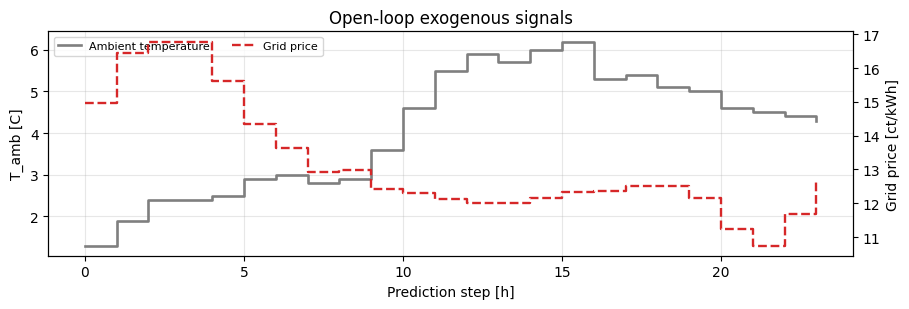

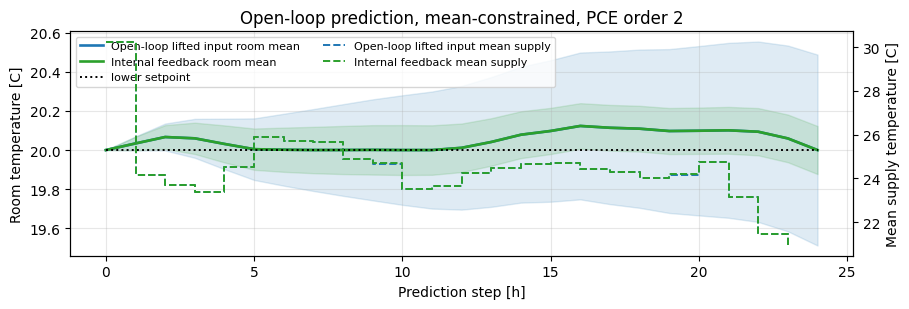

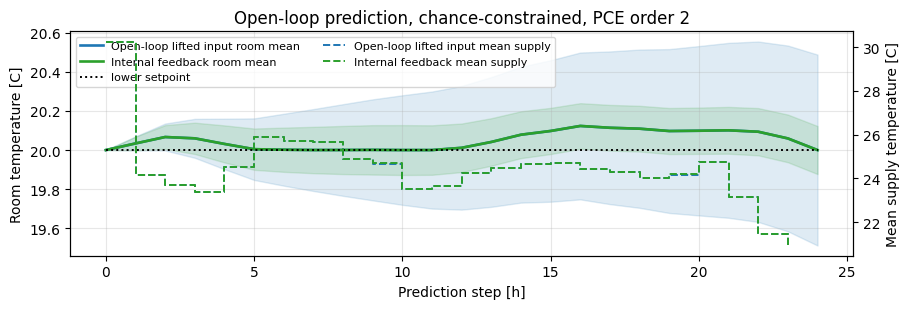

In [7]:
hours_state = np.arange(nk + 1) * h / 3600.0
hours_control = np.arange(nk) * h / 3600.0

fig, ax_temp = plt.subplots(figsize=(9.2, 3.2))
ax_price = ax_temp.twinx()
ax_temp.step(
    hours_control,
    open_loop_disturbances["T_amb"].iloc[:nk].to_numpy(dtype=float),
    where="post",
    color="tab:gray",
    linewidth=1.9,
    label="Ambient temperature",
)
ax_price.step(
    hours_control,
    open_loop_disturbances["grid"].iloc[:nk].to_numpy(dtype=float),
    where="post",
    color="tab:red",
    linewidth=1.7,
    linestyle="--",
    label="Grid price",
)
ax_temp.set_title("Open-loop exogenous signals")
ax_temp.set_xlabel("Prediction step [h]")
ax_temp.set_ylabel("T_amb [C]")
ax_price.set_ylabel("Grid price [ct/kWh]")
ax_temp.grid(True, alpha=0.3)
handles_temp, labels_temp = ax_temp.get_legend_handles_labels()
handles_price, labels_price = ax_price.get_legend_handles_labels()
ax_temp.legend(handles_temp + handles_price, labels_temp + labels_price, fontsize=8, ncol=2, loc="best")
plt.tight_layout()
plt.show()

for controller_label in controller_cases:
    fig, ax_room = plt.subplots(figsize=(9.2, 3.2))
    ax_supply = ax_room.twinx()

    for formulation_label, color in formulation_color_map.items():
        result = open_loop_results[formulation_label][controller_label]
        ax_room.fill_between(
            hours_state,
            result["interval_lower"],
            result["interval_upper"],
            color=color,
            alpha=0.14,
        )
        ax_room.plot(
            hours_state,
            result["mean_room"],
            color=color,
            linewidth=1.9,
            label=f"{formulation_label} room mean",
        )
        ax_supply.step(
            hours_control,
            result["u_seq"],
            where="post",
            color=color,
            linestyle="--",
            linewidth=1.4,
            label=f"{formulation_label} mean supply",
        )

    ax_room.plot(
        hours_state,
        next(iter(open_loop_results.values()))[controller_label]["setpoint"],
        "k:",
        linewidth=1.4,
        label="lower setpoint",
    )

    ax_room.set_title(f"Open-loop prediction, {controller_label.lower()}, PCE order {pce_order}")
    ax_room.set_xlabel("Prediction step [h]")
    ax_room.set_ylabel("Room temperature [C]")
    ax_supply.set_ylabel("Mean supply temperature [C]")
    ax_room.grid(True, alpha=0.3)

    handles_room, labels_room = ax_room.get_legend_handles_labels()
    handles_supply, labels_supply = ax_supply.get_legend_handles_labels()
    ax_room.legend(handles_room + handles_supply, labels_room + labels_supply, fontsize=8, ncol=2, loc="best")

    plt.tight_layout()
    plt.show()


## Interpretation Of The Exogenous Signals

The two exogenous signals act on the control through different mechanisms:

- **Ambient temperature `T_amb`** enters the building dynamics directly. When `T_amb` drops, heat losses increase and the optimizer tends to raise the mean supply temperature to keep the room above the comfort limit.
- **Grid price** enters only through the objective. High-price hours make heating more expensive, so the optimizer tends to reduce or postpone heating in those periods whenever the room-temperature constraint still allows it.
- When prices are lower, the controller can shift some heating earlier and use mild preheating, which is visible as higher mean supply before expensive hours.
- In closed loop, this trade-off is repeated at every MPC update: weather drives the thermal need, while the price signal decides **when** it is cheapest to deliver that heat.


## Closed-Loop PCE Propagation With Receding-Horizon Re-Optimization

The closed-loop rollout below still re-solves the MPC each step, but the PCE state propagation inside the model differs:

- `Open-loop lifted input`: higher control coefficients remain zero.
- `Internal feedback`: higher control coefficients are generated automatically as `u^(ℓ)=K x^(ℓ)`.

For the closed-loop comparison, the summary uses the accumulated executed one-step stage cost. Each MPC solve produces a full horizon plan, but only the first control move is applied before the problem is solved again at the next time step.


In [8]:
def rollout_closed_loop_pce_case(building_model, formulation_label, controller_label, chance_epsilon):
    x_pc = building_model.lift_deterministic_state(x0_det)
    room_idx = building_model.base_state_keys.index("T_room")
    ret_idx = building_model.base_state_keys.index("T_hp_ret")
    setpoint_col = disturbance_cols.index("T_room_set_lower")
    interval_z = NormalDist().inv_cdf(0.5 + 0.5 * closed_loop_interval_level)

    mpc = build_intrusive_mpc_solver(
        hp_model=hp_model,
        building_model=building_model,
        disturbance_count=len(disturbance_cols),
        h=h,
        nk=nk,
        ws=ws,
        resultdir="results_intrusive_pce",
        resultfile=f"internal_feedback_closed_loop_{formulation_label.lower().replace(' ', '_')}_{controller_label.lower().replace(' ', '_')}",
        chance_epsilon=chance_epsilon,
        soft_lower_constraint=soft_lower_constraint,
    )

    mean_state_0 = building_model.mean_state(x_pc)
    var_state_0 = building_model.variance_state(x_pc)
    room_mean = [float(mean_state_0[room_idx])]
    room_std = [float(np.sqrt(var_state_0[room_idx]))]
    room_lower = [float(lower_quantile_from_moments(np.array([room_mean[0]]), np.array([room_std[0]]), eps_chance)[0])]
    room_interval_lower = [float(room_mean[0] - interval_z * room_std[0])]
    room_interval_upper = [float(room_mean[0] + interval_z * room_std[0])]
    setpoint = [float(disturbances_df.iloc[0, setpoint_col])]
    mean_supply = []
    mean_hp_power_kw = []
    input_std = []
    realized_stage_values = []
    mean_margin = []
    lower_margin = []
    formulation_margin = []

    for step in range(closed_loop_steps):
        window = disturbances_df.iloc[step : step + nk + 1].copy()
        if len(window) < nk + 1:
            break

        P = window.loc[:, disturbance_cols].to_numpy()
        mean_state_now = building_model.mean_state(x_pc)
        ret_mean_now = float(mean_state_now[ret_idx])
        mpc.update_NLP(x_pc)
        uk, _, res = mpc.solve_NLP(P, return_res=True)
        v_now = float(np.asarray(uk).reshape(-1)[0])
        u_coeffs_now = control_coefficients_from_trajectory(building_model, np.asarray([x_pc]), np.asarray([v_now]))[0]
        realized_stage_values.append(float(realized_stage_cost(hp_model, building_model, x_pc, v_now, P[0])))

        x_pred_traj, _, _ = extract_intrusive_trajectory(res["x"], mpc)
        x_pc = np.asarray(x_pred_traj[1], dtype=float)

        mean_state_next = building_model.mean_state(x_pc)
        var_state_next = building_model.variance_state(x_pc)
        room_mean_next = float(mean_state_next[room_idx])
        room_std_next = float(np.sqrt(var_state_next[room_idx]))
        room_lower_next = float(lower_quantile_from_moments(np.array([room_mean_next]), np.array([room_std_next]), eps_chance)[0])
        setpoint_next = float(disturbances_df.iloc[step + 1, setpoint_col])

        room_mean.append(room_mean_next)
        room_std.append(room_std_next)
        room_lower.append(room_lower_next)
        room_interval_lower.append(room_mean_next - interval_z * room_std_next)
        room_interval_upper.append(room_mean_next + interval_z * room_std_next)
        setpoint.append(setpoint_next)
        mean_supply.append(v_now)
        mean_hp_power_kw.append(float(hp_model.mdot_HP * hp_model.c_water * (v_now - ret_mean_now) / 1000.0))
        input_std.append(float(np.sqrt(np.sum(u_coeffs_now[1:] ** 2))))
        mean_margin.append(room_mean_next - setpoint_next)
        lower_margin.append(room_lower_next - setpoint_next)

        if chance_epsilon is None:
            formulation_margin.append(room_mean_next - setpoint_next)
        else:
            formulation_margin.append(room_lower_next - setpoint_next)

    n_state = len(room_mean)
    n_control = len(mean_supply)
    return {
        "formulation": formulation_label,
        "controller": controller_label,
        "chance_epsilon": chance_epsilon,
        "realized_cost_total": float(np.sum(realized_stage_values)),
        "realized_stage_values": np.asarray(realized_stage_values),
        "room_mean": np.asarray(room_mean),
        "room_std": np.asarray(room_std),
        "room_lower": np.asarray(room_lower),
        "room_interval_lower": np.asarray(room_interval_lower),
        "room_interval_upper": np.asarray(room_interval_upper),
        "setpoint": np.asarray(setpoint),
        "mean_supply": np.asarray(mean_supply),
        "mean_hp_power_kw": np.asarray(mean_hp_power_kw),
        "input_std": np.asarray(input_std),
        "mean_margin": np.asarray(mean_margin),
        "lower_margin": np.asarray(lower_margin),
        "formulation_margin": np.asarray(formulation_margin),
        "time_state_h": np.arange(n_state) * h / 3600.0,
        "time_control_h": np.arange(n_control) * h / 3600.0,
    }


closed_loop_results = {
    formulation_label: {
        controller_label: rollout_closed_loop_pce_case(building_model, formulation_label, controller_label, chance_epsilon)
        for controller_label, chance_epsilon in controller_cases.items()
    }
    for formulation_label, building_model in formulations.items()
}

closed_loop_summary_rows = []
for formulation_label, formulation_results in closed_loop_results.items():
    for controller_label, result in formulation_results.items():
        closed_loop_summary_rows.append(
            {
                "formulation": formulation_label,
                "controller": controller_label,
                "realized_cost_total": result["realized_cost_total"],
                "min_formulation_margin_C": float(np.min(result["formulation_margin"])) if len(result["formulation_margin"]) else np.nan,
                "mean_input_std_C": float(np.mean(result["input_std"])) if len(result["input_std"]) else 0.0,
                "terminal_room_std_C": float(result["room_std"][-1]),
            }
        )

closed_loop_summary = pd.DataFrame(closed_loop_summary_rows)
closed_loop_summary

,formulation,controller,realized_cost_total,min_formulation_margin_C,mean_input_std_C,terminal_room_std_C
0,Open-loop lifted input,Mean-constrained,2.088664,-9.991204e-09,0.000000,0.249387
1,Open-loop lifted input,Chance-constrained,3.067877,-1.644423e-04,0.000000,0.254277
2,Internal feedback,Mean-constrained,2.090413,-9.991204e-09,0.466364,0.062999
3,Internal feedback,Chance-constrained,2.789275,-1.643694e-04,0.471680,0.063453


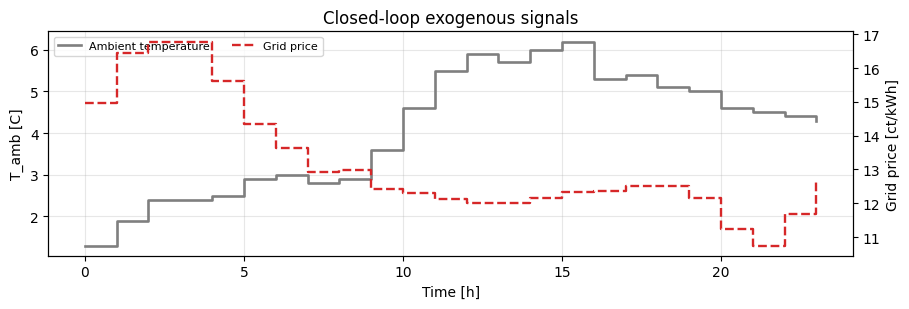

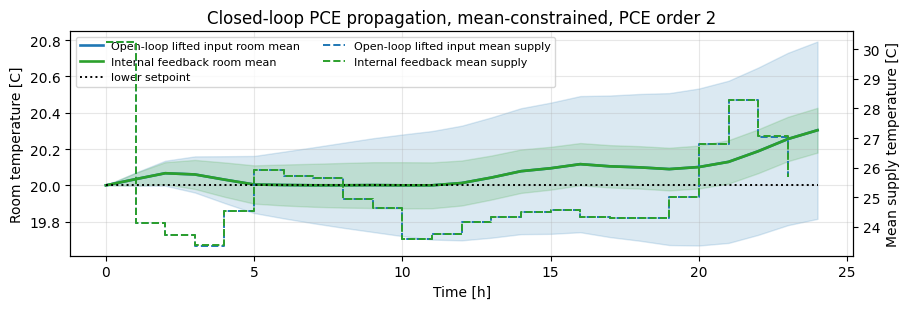

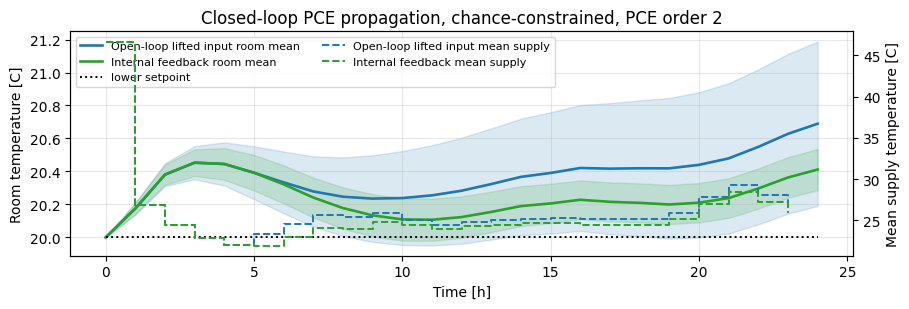

In [9]:
fig, ax_temp = plt.subplots(figsize=(9.2, 3.2))
ax_price = ax_temp.twinx()
closed_loop_hours_control = np.arange(closed_loop_steps) * h / 3600.0
ax_temp.step(
    closed_loop_hours_control,
    closed_loop_disturbances["T_amb"].iloc[:closed_loop_steps].to_numpy(dtype=float),
    where="post",
    color="tab:gray",
    linewidth=1.9,
    label="Ambient temperature",
)
ax_price.step(
    closed_loop_hours_control,
    closed_loop_disturbances["grid"].iloc[:closed_loop_steps].to_numpy(dtype=float),
    where="post",
    color="tab:red",
    linewidth=1.7,
    linestyle="--",
    label="Grid price",
)
ax_temp.set_title("Closed-loop exogenous signals")
ax_temp.set_xlabel("Time [h]")
ax_temp.set_ylabel("T_amb [C]")
ax_price.set_ylabel("Grid price [ct/kWh]")
ax_temp.grid(True, alpha=0.3)
handles_temp, labels_temp = ax_temp.get_legend_handles_labels()
handles_price, labels_price = ax_price.get_legend_handles_labels()
ax_temp.legend(handles_temp + handles_price, labels_temp + labels_price, fontsize=8, ncol=2, loc="best")
plt.tight_layout()
plt.show()

for controller_label in controller_cases:
    fig, ax_room = plt.subplots(figsize=(9.2, 3.2))
    ax_supply = ax_room.twinx()

    for formulation_label, color in formulation_color_map.items():
        result = closed_loop_results[formulation_label][controller_label]
        ax_room.fill_between(
            result["time_state_h"],
            result["room_interval_lower"],
            result["room_interval_upper"],
            color=color,
            alpha=0.16,
        )
        ax_room.plot(
            result["time_state_h"],
            result["room_mean"],
            color=color,
            linewidth=1.9,
            label=f"{formulation_label} room mean",
        )
        ax_supply.step(
            result["time_control_h"],
            result["mean_supply"],
            where="post",
            color=color,
            linewidth=1.4,
            linestyle="--",
            label=f"{formulation_label} mean supply",
        )

    setpoint = closed_loop_results["Open-loop lifted input"][controller_label]["setpoint"]
    time_state = closed_loop_results["Open-loop lifted input"][controller_label]["time_state_h"]
    ax_room.plot(time_state, setpoint, "k:", linewidth=1.4, label="lower setpoint")

    ax_room.set_title(f"Closed-loop PCE propagation, {controller_label.lower()}, PCE order {pce_order}")
    ax_room.set_xlabel("Time [h]")
    ax_room.set_ylabel("Room temperature [C]")
    ax_supply.set_ylabel("Mean supply temperature [C]")
    ax_room.grid(True, alpha=0.3)

    handles_room, labels_room = ax_room.get_legend_handles_labels()
    handles_supply, labels_supply = ax_supply.get_legend_handles_labels()
    ax_room.legend(handles_room + handles_supply, labels_room + labels_supply, fontsize=8, ncol=2, loc="best")

    plt.tight_layout()
    plt.show()


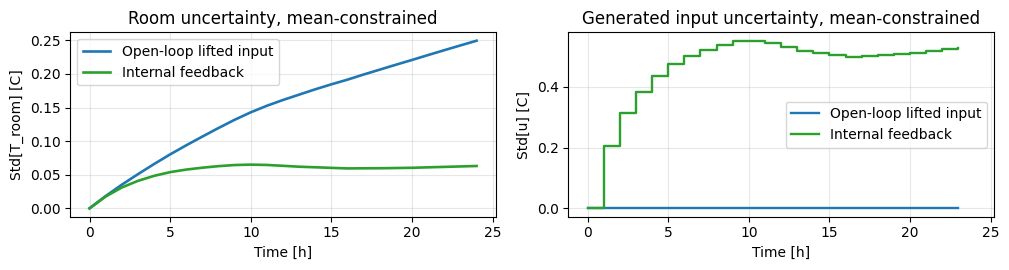

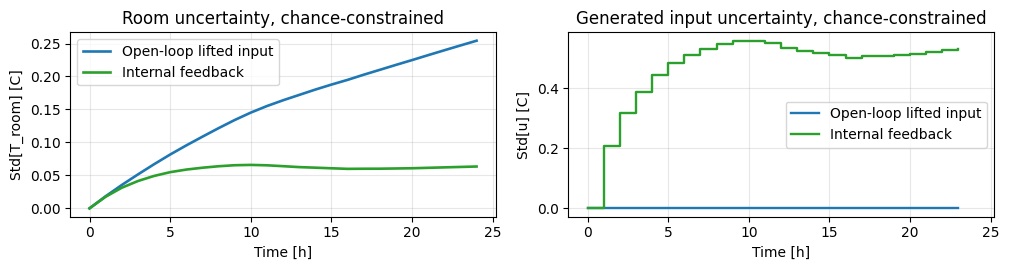

In [10]:

for controller_label in controller_cases:
    fig, axes = plt.subplots(1, 2, figsize=(10.2, 2.8), sharex=True)

    for formulation_label, color in formulation_color_map.items():
        result = closed_loop_results[formulation_label][controller_label]
        axes[0].plot(
            result["time_state_h"],
            result["room_std"],
            color=color,
            linewidth=1.9,
            label=formulation_label,
        )
        axes[1].step(
            result["time_control_h"],
            result["input_std"],
            where="post",
            color=color,
            linewidth=1.7,
            label=formulation_label,
        )

    axes[0].set_title(f"Room uncertainty, {controller_label.lower()}")
    axes[1].set_title(f"Generated input uncertainty, {controller_label.lower()}")
    axes[0].set_ylabel("Std[T_room] [C]")
    axes[1].set_ylabel("Std[u] [C]")
    for ax in axes:
        ax.set_xlabel("Time [h]")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


## Monte Carlo Validation Of The Four Controller Variants

The PCE prediction plots above describe what each controller *predicts*. The Monte Carlo block below validates what happens on sampled deterministic plants drawn from the same uncertainty model:

- uncertainty samples are drawn as `xi ~ N(0, I)`
- the same `xi` samples are used for all four controller variants
- the **violation rate** is computed on the realized deterministic room trajectory
- the **average objective value** is computed from realized cumulative stage cost

The main reported violation metric is:
- `step_violation_rate`: fraction of all simulated time steps that violate the lower comfort bound

This is the quantity that should be compared to a per-time-step chance constraint such as `epsilon = 0.05`.

Additional violation magnitudes are also reported:
- `mean_violation_C`: average comfort shortfall `max(T_set_lower - T_room, 0)` over all simulated time steps
- `max_violation_C`: worst comfort shortfall observed over all simulated time steps

The notebook now defaults to `mc_sample_count = 100`, which gives a more stable estimate of the time-step violation rate but also makes the Monte Carlo block noticeably slower to run.


In [11]:
from copy import deepcopy

from src.simulator import Model_simulator

mc_sample_count = 100
mc_random_seed = 7
mc_eval_epsilon = eps_chance


def deterministic_building_from_xi(xi_sample):
    xi_sample = np.asarray(xi_sample, dtype=float).reshape(-1)
    theta_sample = theta_bar + L @ xi_sample
    params_sample = deepcopy(i4c)
    for idx, key in enumerate(open_loop_building.uncertain_param_keys):
        params_sample[key] = float(i4c[key] * theta_sample[idx])
    return model_buildings.Building(
        params=params_sample,
        mdot_hp=mdot_hp,
        method=method,
        T_room_set_lower=20,
    )


def summarize_mc_rows(rows_df):
    grouped = []
    for (phase, formulation, controller), group in rows_df.groupby(["phase", "formulation", "controller"], sort=True):
        sample_group = group.groupby("sample_index", sort=True)
        realized_cost_total = sample_group["realized_stage_cost"].sum()
        violating_step = group["violation_C"] > 1e-9
        grouped.append(
            {
                "phase": phase,
                "formulation": formulation,
                "controller": controller,
                "samples": int(sample_group.ngroups),
                "avg_realized_cost_total": float(realized_cost_total.mean()),
                "step_violation_rate": float(violating_step.mean()),
                #"mean_violation_C": float(group["violation_C"].mean()),
                #"max_violation_C": float(group["violation_C"].max()),
            }
        )
    return pd.DataFrame(grouped).sort_values(["phase", "controller", "formulation"]).reset_index(drop=True)


def monte_carlo_open_loop_case(building_model, formulation_label, controller_label, chance_epsilon, xi_samples):
    x0_pc = building_model.lift_deterministic_state(x0_det)
    P0 = open_loop_disturbances.loc[:, disturbance_cols].to_numpy()

    mpc = build_intrusive_mpc_solver(
        hp_model=hp_model,
        building_model=building_model,
        disturbance_count=len(disturbance_cols),
        h=h,
        nk=nk,
        ws=ws,
        resultdir="results_intrusive_pce",
        resultfile=f"mc_open_loop_{formulation_label.lower().replace(' ', '_')}_{controller_label.lower().replace(' ', '_')}",
        chance_epsilon=chance_epsilon,
        soft_lower_constraint=soft_lower_constraint,
    )
    mpc.update_NLP(x0_pc)
    _, _, res = mpc.solve_NLP(P0, return_res=True)
    _, u_seq, _ = extract_intrusive_trajectory(res["x"], mpc)
    u_seq = np.asarray(u_seq, dtype=float).reshape(-1)

    rows = []
    room_idx = nominal_building.state_keys.index("T_room")
    setpoint_idx = disturbance_cols.index("T_room_set_lower")

    for sample_index, xi_sample in enumerate(xi_samples):
        simulator = Model_simulator(hp_model, deterministic_building_from_xi(xi_sample), h)
        x_true = x0_det.copy()
        for step in range(min(nk, len(u_seq))):
            u_now = float(u_seq[step])
            stage_cost = float(realized_stage_cost(hp_model, simulator.bldg_model, x_true, u_now, P0[step]))
            next_state = simulator.get_next_state(
                x_init={key: float(val) for key, val in zip(nominal_building.state_keys, x_true)},
                uk=u_now,
                pk=open_loop_disturbances.iloc[step].to_dict(),
            )["state"]
            x_true = np.asarray([next_state[key] for key in nominal_building.state_keys], dtype=float)
            set_low_next = float(P0[step + 1, setpoint_idx])
            violation = max(set_low_next - float(x_true[room_idx]), 0.0)
            rows.append(
                {
                    "phase": "Open-loop plan execution",
                    "formulation": formulation_label,
                    "controller": controller_label,
                    "sample_index": int(sample_index),
                    "step": int(step + 1),
                    "realized_stage_cost": stage_cost,
                    "violation_C": float(violation),
                }
            )
    return pd.DataFrame(rows)


def monte_carlo_closed_loop_case(building_model, formulation_label, controller_label, chance_epsilon, xi_samples):
    rows = []
    room_idx = nominal_building.state_keys.index("T_room")
    setpoint_idx = disturbance_cols.index("T_room_set_lower")

    for sample_index, xi_sample in enumerate(xi_samples):
        simulator = Model_simulator(hp_model, deterministic_building_from_xi(xi_sample), h)
        x_true = x0_det.copy()
        x_pc = building_model.lift_deterministic_state(x0_det)

        mpc = build_intrusive_mpc_solver(
            hp_model=hp_model,
            building_model=building_model,
            disturbance_count=len(disturbance_cols),
            h=h,
            nk=nk,
            ws=ws,
            resultdir="results_intrusive_pce",
            resultfile=f"mc_closed_loop_{formulation_label.lower().replace(' ', '_')}_{controller_label.lower().replace(' ', '_')}_sample{sample_index}",
            chance_epsilon=chance_epsilon,
            soft_lower_constraint=soft_lower_constraint,
        )

        for step in range(closed_loop_steps):
            window = disturbances_df.iloc[step : step + nk + 1].copy()
            if len(window) < nk + 1:
                break
            P = window.loc[:, disturbance_cols].to_numpy()
            mpc.update_NLP(x_pc)
            uk, _, res = mpc.solve_NLP(P, return_res=True)
            u_now = float(np.asarray(uk).reshape(-1)[0])
            stage_cost = float(realized_stage_cost(hp_model, simulator.bldg_model, x_true, u_now, P[0]))
            x_pred_traj, _, _ = extract_intrusive_trajectory(res["x"], mpc)
            x_pc = np.asarray(x_pred_traj[1], dtype=float)

            next_state = simulator.get_next_state(
                x_init={key: float(val) for key, val in zip(nominal_building.state_keys, x_true)},
                uk=u_now,
                pk=window.iloc[0].to_dict(),
            )["state"]
            x_true = np.asarray([next_state[key] for key in nominal_building.state_keys], dtype=float)
            set_low_next = float(P[1, setpoint_idx])
            violation = max(set_low_next - float(x_true[room_idx]), 0.0)
            rows.append(
                {
                    "phase": "Closed-loop rollout",
                    "formulation": formulation_label,
                    "controller": controller_label,
                    "sample_index": int(sample_index),
                    "step": int(step + 1),
                    "realized_stage_cost": stage_cost,
                    "violation_C": float(violation),
                }
            )
    return pd.DataFrame(rows)


rng = np.random.default_rng(mc_random_seed)
xi_samples = rng.normal(size=(mc_sample_count, open_loop_building.uncertain_dim))

mc_rows = []
for formulation_label, building_model in formulations.items():
    for controller_label, chance_epsilon in controller_cases.items():
        mc_rows.append(
            monte_carlo_open_loop_case(building_model, formulation_label, controller_label, chance_epsilon, xi_samples)
        )
        mc_rows.append(
            monte_carlo_closed_loop_case(building_model, formulation_label, controller_label, chance_epsilon, xi_samples)
        )

mc_step_metrics = pd.concat(mc_rows, ignore_index=True)
mc_summary = summarize_mc_rows(mc_step_metrics)
mc_summary


AttributeError: 'Building' object has no attribute 'return_temperature_expr'

,phase,formulation,controller,samples,avg_realized_cost_total,step_violation_rate
0,Closed-loop rollout,Internal feedback,Chance-constrained,100,2.780292,0.058333
1,Closed-loop rollout,Open-loop lifted input,Chance-constrained,100,3.058784,0.003333
2,Closed-loop rollout,Internal feedback,Mean-constrained,100,2.081180,0.254583
3,Closed-loop rollout,Open-loop lifted input,Mean-constrained,100,2.079544,0.256250


,phase,formulation,controller,samples,avg_realized_cost_total,step_violation_rate
0,Open-loop plan execution,Internal feedback,Chance-constrained,100,2.419335,0.080417
1,Open-loop plan execution,Open-loop lifted input,Chance-constrained,100,2.704527,0.003750
2,Open-loop plan execution,Internal feedback,Mean-constrained,100,1.725556,0.286250
3,Open-loop plan execution,Open-loop lifted input,Mean-constrained,100,1.724121,0.286667


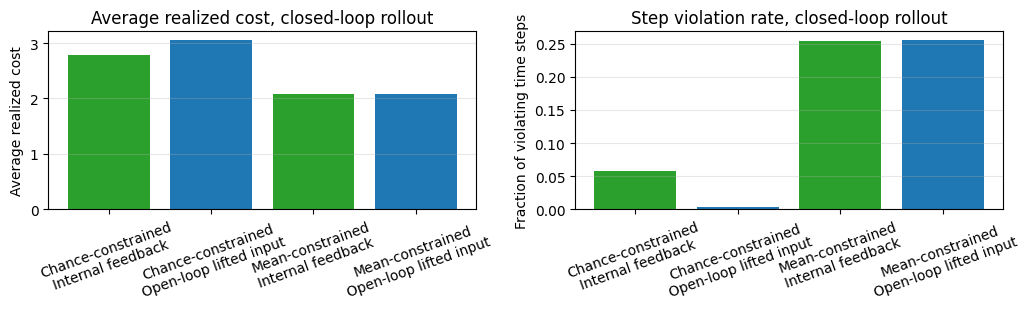

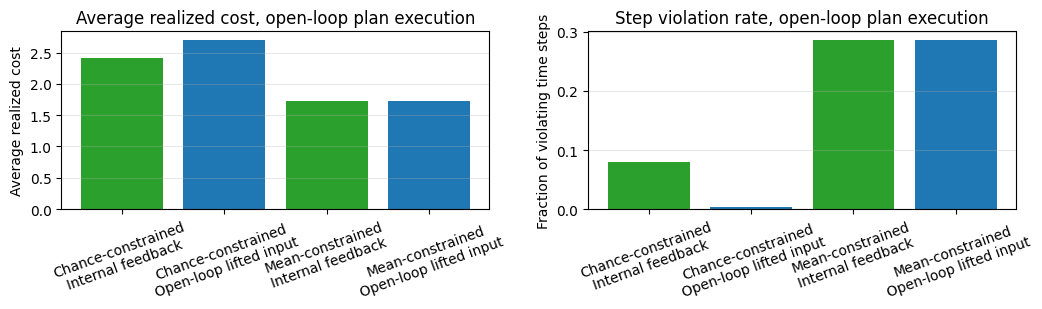

In [ ]:
for phase, phase_df in mc_summary.groupby("phase", sort=False):
    try:
        display(phase_df.reset_index(drop=True))
    except NameError:
        print(phase_df.reset_index(drop=True).to_string(index=False))

for phase, phase_df in mc_summary.groupby("phase", sort=False):
    fig, axes = plt.subplots(1, 2, figsize=(10.6, 3.2))
    phase_plot = phase_df.copy()
    phase_plot["label"] = phase_plot["controller"] + "\n" + phase_plot["formulation"]

    colors = [formulation_color_map[label] for label in phase_plot["formulation"]]

    axes[0].bar(phase_plot["label"], phase_plot["avg_realized_cost_total"], color=colors)
    axes[0].set_title(f"Average realized cost, {phase.lower()}")
    axes[0].set_ylabel("Average realized cost")
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].grid(True, axis="y", alpha=0.3)

    axes[1].bar(phase_plot["label"], phase_plot["step_violation_rate"], color=colors)
    axes[1].set_title(f"Step violation rate, {phase.lower()}")
    axes[1].set_ylabel("Fraction of violating time steps")
    axes[1].tick_params(axis="x", rotation=20)
    axes[1].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


## Focused Comparison: Closed-Loop Internal Feedback

The plots below isolate the two **closed-loop internal-feedback** variants:
- mean-constrained MPC
- chance-constrained MPC

The trajectory plot compares the internal-feedback room-temperature mean against the relevant constraint information.
The bar plot then compares the corresponding **Monte Carlo** average realized cost and the realized **time-step violation rate**.


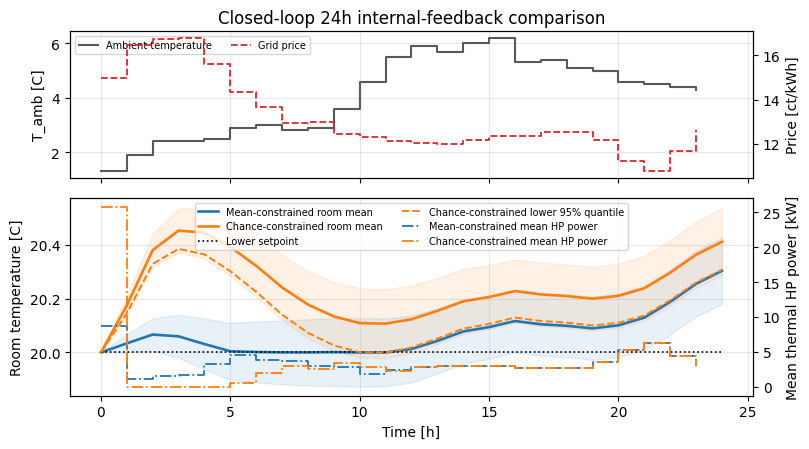

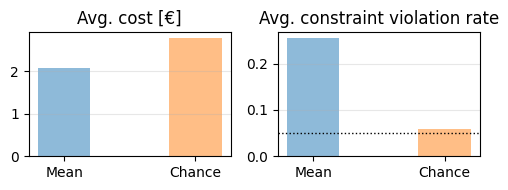

In [ ]:
internal_feedback_mean = closed_loop_results["Internal feedback"]["Mean-constrained"]
internal_feedback_chance = closed_loop_results["Internal feedback"]["Chance-constrained"]
comparison_colors = {
    "Mean-constrained": "tab:blue",
    "Chance-constrained": "tab:orange",
}

fig, axes = plt.subplots(
    2,
    1,
    figsize=(8.2, 4.6),
    sharex=True,
    gridspec_kw={"height_ratios": [1.0, 1.35]},
)

ax_exog = axes[0]
ax_price = ax_exog.twinx()
closed_loop_hours_control = np.arange(closed_loop_steps) * h / 3600.0
ax_exog.step(
    closed_loop_hours_control,
    closed_loop_disturbances["T_amb"].iloc[:closed_loop_steps].to_numpy(dtype=float),
    where="post",
    color="0.35",
    linewidth=1.5,
    label="Ambient temperature",
)
ax_price.step(
    closed_loop_hours_control,
    closed_loop_disturbances["grid"].iloc[:closed_loop_steps].to_numpy(dtype=float),
    where="post",
    color="tab:red",
    linewidth=1.3,
    linestyle="--",
    label="Grid price",
)
ax_exog.set_ylabel("T_amb [C]")
ax_price.set_ylabel("Price [ct/kWh]")
ax_exog.set_title("Closed-loop 24h internal-feedback comparison")
ax_exog.grid(True, alpha=0.3)
handles_exog, labels_exog = ax_exog.get_legend_handles_labels()
handles_price, labels_price = ax_price.get_legend_handles_labels()
ax_exog.legend(handles_exog + handles_price, labels_exog + labels_price, fontsize=7, ncol=3, loc="upper left")

ax_room = axes[1]
ax_power = ax_room.twinx()
for controller_label, result in [
    ("Mean-constrained", internal_feedback_mean),
    ("Chance-constrained", internal_feedback_chance),
]:
    color = comparison_colors[controller_label]
    ax_room.fill_between(
        result["time_state_h"],
        result["room_interval_lower"],
        result["room_interval_upper"],
        color=color,
        alpha=0.10,
    )
    ax_room.plot(
        result["time_state_h"],
        result["room_mean"],
        color=color,
        linewidth=1.9,
        label=f"{controller_label} room mean",
    )
    ax_power.step(
        result["time_control_h"],
        result["mean_hp_power_kw"],
        where="post",
        color=color,
        linewidth=1.3,
        linestyle="-.",
        label=f"{controller_label} mean HP power",
    )

ax_room.plot(
    internal_feedback_mean["time_state_h"],
    internal_feedback_mean["setpoint"],
    color="black",
    linestyle=":",
    linewidth=1.2,
    label="Lower setpoint",
)
ax_room.plot(
    internal_feedback_chance["time_state_h"],
    internal_feedback_chance["room_lower"],
    color=comparison_colors["Chance-constrained"],
    linestyle="--",
    linewidth=1.4,
    label="Chance-constrained lower 95% quantile",
)
ax_room.set_xlabel("Time [h]")
ax_room.set_ylabel("Room temperature [C]")
ax_power.set_ylabel("Mean thermal HP power [kW]")
ax_room.grid(True, alpha=0.3)
handles_room, labels_room = ax_room.get_legend_handles_labels()
handles_power, labels_power = ax_power.get_legend_handles_labels()
ax_room.legend(handles_room + handles_power, labels_room + labels_power, fontsize=7, ncol=2, loc="best")

plt.tight_layout()
plt.show()

internal_feedback_mc = mc_summary[
    (mc_summary["phase"] == "Closed-loop rollout")
    & (mc_summary["formulation"] == "Internal feedback")
].copy()
internal_feedback_mc = internal_feedback_mc.set_index("controller").loc[["Mean-constrained", "Chance-constrained"]].reset_index()
internal_feedback_mc["label"] = ["Mean", "Chance"]
bar_colors = [comparison_colors[label] for label in internal_feedback_mc["controller"]]

fig, axes = plt.subplots(1, 2, figsize=(5., 2.))
axes[0].bar(internal_feedback_mc["label"], internal_feedback_mc["avg_realized_cost_total"], color=bar_colors, width=0.4, alpha=0.50)
axes[0].set_title("Avg. cost [€]")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(internal_feedback_mc["label"], internal_feedback_mc["step_violation_rate"], color=bar_colors, width=0.4, alpha=0.50)
axes[1].axhline(eps_chance, color="black", linestyle=":", linewidth=1.)
axes[1].set_title("Avg. constraint violation rate")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
